In [1]:
import os
output = os.listdir("./platform-examples/output")

In [ ]:
# ids = ['rI2Fa13fUL', 'U6ROetm5nW', 'PFhrOUJZ5o', 'Pa6ak2B9jJ', 'zKQSyT7a7n', 'X2yzXtH4wp', 'MwuSvrthXq', 'iDki7djO2K', 'wUzBBsrdB1', '2EQPpEZtEK', 'NfO2Lt2WY7', 'NFB4QGGS65', 'WwDNiisZQm', 'eETr3lrOQB', 'OuMNJoKJBQ', 'RpDJz00zNh', 'XX5EZoe4ec', 'dCtkwjkK0E', 'crKJJ4Ej60', 'b6qQmQ2F13', 'ey7CXUBn1g', '31CznLfRIS', 'Rt9SeEAMWv', 'ppXAVexrAM', 'Me0n0iESJY', 'wSbVv6xaRr', 'd2pUyiXwcm', 'ZNAY3ivd62', 'GRufFX1gAy', 'KsWRLyIAKP', 'iaoAKDRAJQ', 'oh9ChF7Pv0', 'c2ozZYoZFd', 'j3htU5i01r', 'WhO6Km5Rku', 'tswBfpkwHn', 'bH5M0ts8Y6', '1E4Bltg6Xb', 'khHNHzRjMy', 'ZMzha5gbnF', 'xFo13SaHQm', 'cZFgsLq8Gs', 'bm3rbtEMFj', 'JEN4nsDgh9', 'GMP1S4R6Ke', 'aiM6bRd6bG', 'vGkXf8nvt9', 'oiz0QHejVj', 'c7OsKOOZo8', 'Iq1fNZus2W', 'hQZQVLJrH9', 'IdJakw2jta', 'rBj2iVyrhh', 'Vit5M0G5Gb', 'Kw2mvnzCoc', 'opU91paIvZ', 'pNpnqsn0Si', 'Mz98kwANpF', 'USyGD0eUod', 'piylyBPSau', 'khBHJz2wcV', 'GiaF5cFIpI', '32mrjmaeMP', 'M14YpuTejd', 'XIAta0WOJ6', 'sh1hWO9RHo', 'x6bG2Hoqdf', 'CQ0U1wZYoy', 'mDuTDAK6KU', '1j0ormf8uI', 'ZBhZT307xx', 'D5PJX02Jki', 'iIEEgI6WsF', 'Ksvv8x00eo', '41JeFWdVFa', '4Ha2srdhPN', 'QryPmx2MNh', '7L7kmHHfgf', '7yvz93kBw9', 'W42oLSwI9p', 'C6WWMryELL', '0cbUKCyBsH', 'XKLPlnfZzM', 'ngOOlatCK6', 'DZUehXNiBn', 'Vgm77U4ojX', 'VgVeQpagf7', '1EdAn5gMVv', 'v05SW2X3IC', 'cEXEmyW77N', 'FlcMckO6x5', 'qSak1Hjfdq', '3icvqeC1sA', 'kMfVTka2WB', 's7oURFZTQD', 'ahpO7S1Ppi', 'sJxBWDc8SM', 'CTEXdHB1BB']

In [2]:
reviews = {}
filenames = {}
for filename in output:
    with open(f"./platform-examples/output/{filename}", "r") as f:
        # if filename.split("__")[0] in ids:
        #     continue
        reviews[filename.split("__")[0]] = f.read()
        filenames[filename.split("__")[0]] = filename

In [4]:
import sys
sys.path.append("../../../")
from run_iclr_bench import load_ground_truth

Testing ZAI client with a simple call ...


In [7]:
from pathlib import Path
rows, _ = load_ground_truth(Path("../../../iclr2026_unbalanced"))
rows2, _ = load_ground_truth(Path("../../../iclr2026_balanced"))
rows = rows + rows2

In [8]:
gt_dict = {row["paper_id"]: row for row in rows}

In [9]:
next(iter(gt_dict.values()))

{'paper_id': 'ngOOlatCK6',
 'title': 'The Minimal Search Space for Conditional Causal Bandits',
 'scores': [6.0, 6.0, 4.0],
 'avg_score': 5.33,
 'decision': 'Reject',
 'gt_binary': 'Reject'}

In [10]:
import csv
avgs = []
with open("eval_results.csv", "w") as f:
    w = csv.writer(f)
    w.writerow(["paper_id", "pred_score", "pred_decision", "gt_avg_score", "gt_decision", "gt_binary", "match", "cost", "sdk_savings",
                    "gt_score_0", "gt_score_1", "gt_score_2", "gt_score_3", "gt_score_4", "gt_score_5", "gt_score_6"])
for review_item in reviews:
    if review_item.endswith("json"):
        continue
    if "FAILED" in reviews[review_item]:
        continue
    try:
        score = int(reviews[review_item].split("## Overall Rating")[1].split(":")[0].strip())
    except:
        # print("/home/wg25r/review_agent/baselines/cspaper/platform-examples/output/" + filenames[review_item])
        # a bug in CSPaper: no related work will lead to desk reject
        if "Related Work" in reviews[review_item]:
            continue
        else:
            score = 0
    
    r = gt_dict[review_item]
    gt_scores_padded = r["scores"] + [""] * (7 - len(r["scores"]))
    match_str = "N/A"

    with open("eval_results.csv", "a") as f:
        w = csv.writer(f)
        w.writerow([
            review_item,
            score,
            "N/A",
            f"{r['avg_score']:.2f}",
            r["decision"],
            r["gt_binary"],
            match_str,
            f"0.5",
            f"0.0",
            *gt_scores_padded,
        ])
    avgs.append(r['avg_score'])

In [11]:
len(avgs)

171

In [14]:
import numpy as np
np.std(avgs)

np.float64(1.759803759294983)

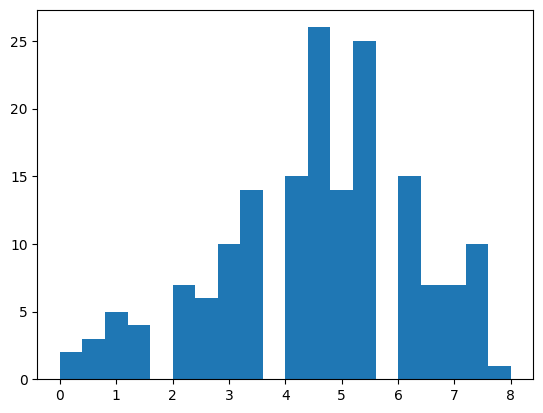

In [12]:
import pylab
pylab.hist(avgs, bins=20)
pylab.show()